# Lista III

## Regularyzacja zadanie na 3.0

Celem jest porownanie modeli bazowych z wersjami regularyzowanymi oraz znalezienie punktu, w ktorym model przestaje sie nadmiernie dopasowywac do zbioru treningowego.

## Przygotowanie danych

W raporcie wykorzystuję dwa zbiory danych, ponieważ poszczególne zadania dotyczą różnych typów problemów. Zbiór Telco Customer Churn służy do zadań klasyfikacyjnych, natomiast zbiór diamonds wykorzystuję w zadaniach regresyjnych, gdzie przewidywana jest wartość price.

Wszystkie porównania modeli oraz prezentowane metryki końcowe zostały obliczone na zbiorze testowym, który nie był wykorzystywany podczas treningu. Dzięki temu wyniki pokazują rzeczywistą zdolność modeli do uogólniania na niewidziane wcześniej dane.

In [1]:

from algorithms.regularization.linear_regularization_comparison import LinearRegularizationComparison
from algorithms.regularization.tree_regularization import TreeRegularizationComparison
from experiments.reporting import (
    show_boosting_report,
    show_final_summary_report,
    show_linear_regularization_report,
    show_mixture_of_experts_report,
    show_stacking_report,
    show_sweet_spot_report,
    show_tree_regularization_report,
)
from utils.file_operations import (
    load_diamonds_data,
    load_telco_data,
    split_diamonds_data,
    split_telco_data,
)
from utils.preprocessing import (
    encode_train_test_features,
    prepare_diamonds_data,
    prepare_linear_regularization_data,
    prepare_telco_data,
)

train_diamonds, test_diamonds = split_diamonds_data(load_diamonds_data())
train_telco, test_telco = split_telco_data(load_telco_data())

X_train_diamonds, y_train_diamonds, X_test_diamonds, y_test_diamonds = prepare_diamonds_data(
    train_diamonds, test_diamonds
)
X_train_telco, y_train_telco, X_test_telco, y_test_telco = prepare_telco_data(
    train_telco, test_telco
)

linear_data = prepare_linear_regularization_data(
    X_train_diamonds, y_train_diamonds, X_test_diamonds, y_test_diamonds
)
X_train_telco_encoded, X_test_telco_encoded = encode_train_test_features(X_train_telco, X_test_telco)

## Lasso i Ridge

Własna implementacja regresji liniowej opiera się na metodzie Gradient Descent. Punkt wyjścia stanowi klasyczna regresja liniowa, w której w każdej iteracji aktualizowane są wagi tak, aby zmniejszać błąd predykcji.
W wersji Ridge do funkcji kosztu dodawana jest kara L2, która zmniejsza wartości wag, ale zwykle ich nie zeruje.
W wersji Lasso dodawana jest kara L1, która nie tylko ogranicza wielkość wag, ale może również wyzerować część z nich, dzięki czemu model działa jednocześnie jako selektor cech.

W praktyce oznacza to, że Ridge stabilizuje model i ogranicza wpływ zbyt dużych współczynników, natomiast Lasso dodatkowo upraszcza model przez usuwanie części cech z rozwiązania. W tym zadaniu sprawdzałem różne wartości parametru alpha, aby znaleźć punkt, w którym regularyzacja poprawia jakość predykcji na zbiorze testowym.

,model_type,alpha,train_mse,test_mse,nonzero_weights,zero_weights,mean_abs_weight,max_abs_weight
0,Ridge,0.0000,1.965359e+06,2.261700e+06,20,0,0.1076,0.9164
1,Ridge,0.0000,1.965359e+06,2.261699e+06,20,0,0.1076,0.9164
2,Ridge,0.0000,1.965359e+06,2.261696e+06,20,0,0.1076,0.9164
3,Ridge,0.0000,1.965365e+06,2.261661e+06,20,0,0.1076,0.9164
4,Ridge,0.0001,1.965424e+06,2.261310e+06,20,0,0.1075,0.9161
5,Ridge,0.0010,1.966089e+06,2.257769e+06,20,0,0.1065,0.9134
6,Ridge,0.0100,1.978396e+06,2.223667e+06,20,0,0.0973,0.8904
7,Ridge,0.1000,2.206637e+06,2.367584e+06,20,0,0.0588,0.7640
8,Ridge,1.0000,4.771878e+06,5.144019e+06,20,0,0.0415,0.3901
9,Ridge,10.0000,1.218241e+07,1.255831e+07,20,0,0.0096,0.0796


,model_type,alpha,train_mse,test_mse,nonzero_weights,zero_weights,mean_abs_weight,max_abs_weight
0,Lasso,0.01,2.007050e+06,2.155471e+06,11,9,0.0706,0.9039
1,Ridge,0.01,1.978396e+06,2.223667e+06,20,0,0.0973,0.8904


,model,train_mse,test_mse,zero_weights
0,baseline GD,1965358.64,2261699.69,0
1,Ridge alpha=1e-02,1978396.17,2223666.92,0
2,Lasso alpha=1e-02,2007049.77,2155471.46,9


,feature,baseline_abs_weight,ridge_abs_weight,lasso_abs_weight,lasso_zero
0,carat,0.9164,0.8904,0.9039,False
1,carat^2,0.3525,0.2950,0.2317,False
2,carat^3,0.3263,0.2190,0.2406,False
3,carat^4,0.1826,0.1696,0.0000,True
4,carat^5,0.0696,0.0825,0.0000,True
5,carat^6,0.0052,0.0249,0.0000,True
6,carat^7,0.0181,0.0019,0.0000,True
7,carat^8,0.0250,0.0137,0.0000,True
8,carat^9,0.0256,0.0185,0.0000,True
9,carat^10,0.0244,0.0203,0.0000,True


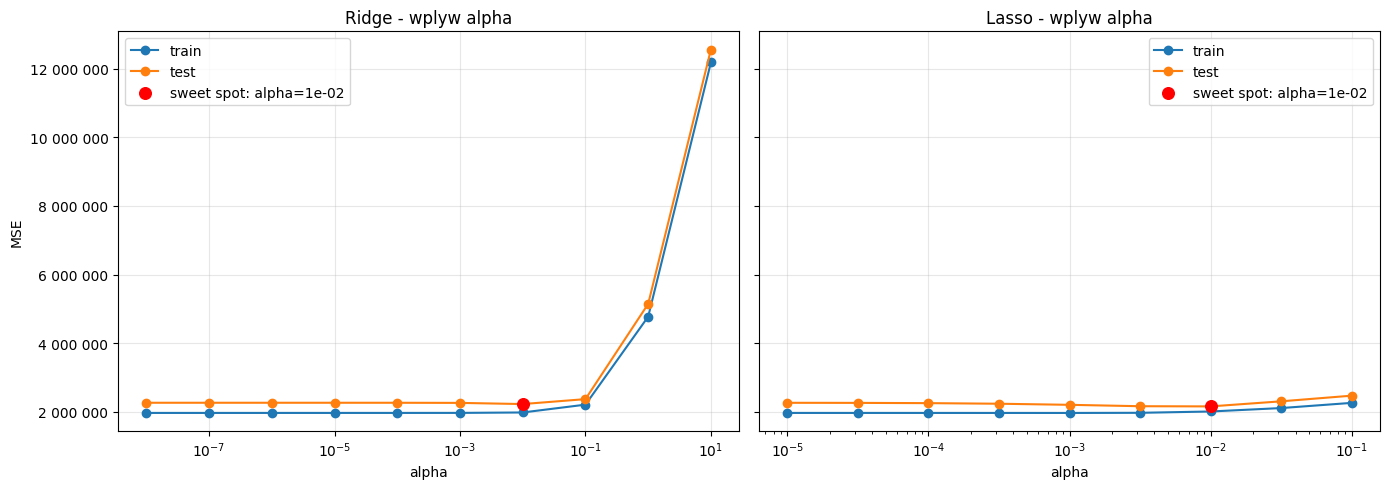

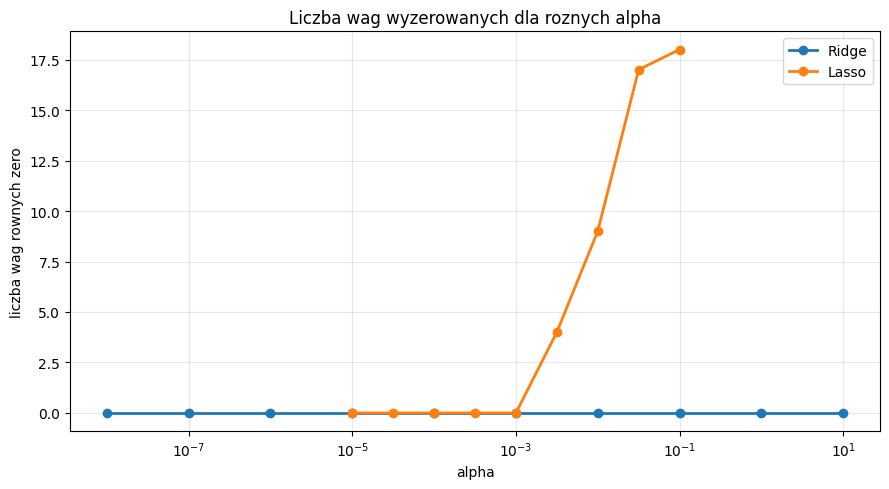

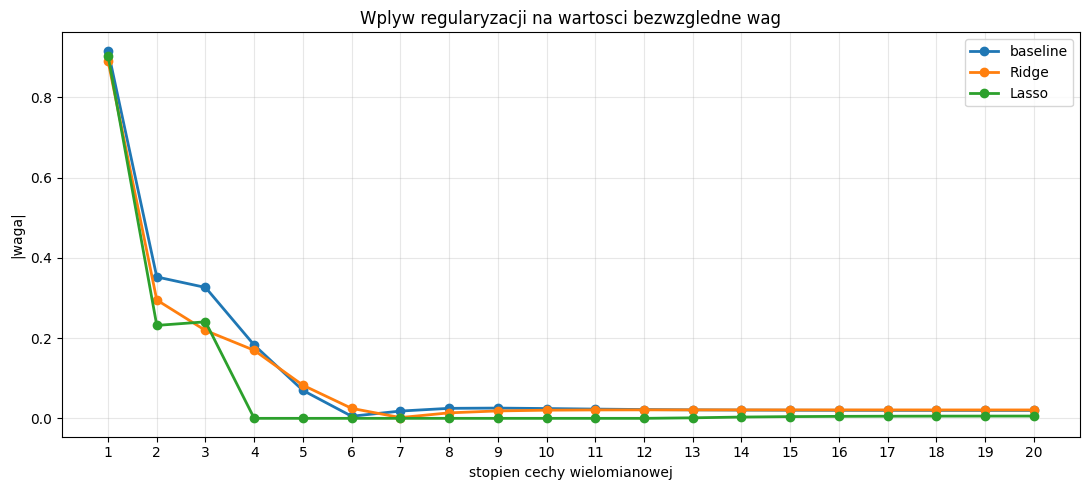

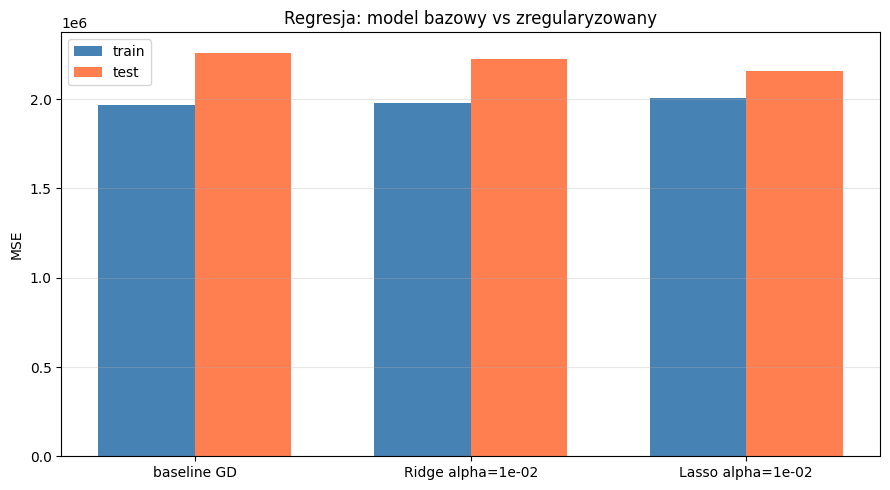

In [2]:
linear_experiment = LinearRegularizationComparison().compare(**linear_data)
show_linear_regularization_report(linear_experiment)

Najlepszy wynik testowy spośród modeli regularyzowanych uzyskał `Lasso`dla alpha = 0.01, gdzie test `SE = 2 155 471.46` Dla porównania najlepszy `Ridge` przy alpha = 0.01 osiągnął test `MSE = 2 223 666.92`, natomiast `model bazowy bez regularyzacji` miał test `MSE = 2 261 699.69`. Oznacza to, że w tym eksperymencie obie formy regularyzacji poprawiły jakość predykcji na zbiorze testowym, ale silniejszy efekt dało Lasso.

Dodatkowo wyniki wag potwierdzają oczekiwane własności obu metod. Ridge zmniejsza wartości współczynników, ale zachowuje wszystkie cechy w modelu. Lasso wyzerowało 9 wag, co potwierdza, że działa nie tylko jako mechanizm ograniczający overfitting, ale również jako prosty selektor cech.

## Regularyzacja drzewa decyzyjnego

W przypadku drzewa decyzyjnego regularyzacja nie polega na dodaniu kary do funkcji kosztu, lecz na ograniczeniu struktury modelu. Parametry takie jak min_samples_split, min_samples_leaf i max_features kontrolują, jak łatwo drzewo może tworzyć kolejne podziały oraz jak szczegółowo dopasowuje się do danych treningowych. Im mniej ograniczeń, tym większe ryzyko nadmiernego dopasowania.

W tym eksperymencie punktem odniesienia było drzewo bazowe, które praktycznie idealnie dopasowywało się do zbioru treningowego, ale wyraźnie gorzej generalizowało na zbiorze testowym. Następnie sprawdzałem, jak zmiana parametrów strukturalnych wpływa na błąd treningowy i testowy.

,parameter,value,label,is_default,train_error,test_error
0,min_samples_split,2,2,True,0.0020,0.2711
1,min_samples_split,5,5,False,0.0410,0.2704
2,min_samples_split,10,10,False,0.0788,0.2654
3,min_samples_split,20,20,False,0.1141,0.2463
4,min_samples_split,40,40,False,0.1479,0.2321
5,min_samples_split,80,80,False,0.1690,0.2207
6,min_samples_split,120,120,False,0.1823,0.2129
7,min_samples_split,200,200,False,0.1919,0.1994
8,min_samples_split,400,400,False,0.1972,0.2016
9,min_samples_leaf,1,1,True,0.0020,0.2711


,parameter,value,label,is_default,train_error,test_error
0,min_samples_split,200,200,False,0.1919,0.1994
1,min_samples_leaf,120,120,False,0.1972,0.2016
2,max_features,0.5,0.5,False,0.0020,0.2718


,model,train_error,test_error
0,baseline tree,0.0020,0.2711
1,min_samples_split=200,0.1919,0.1994


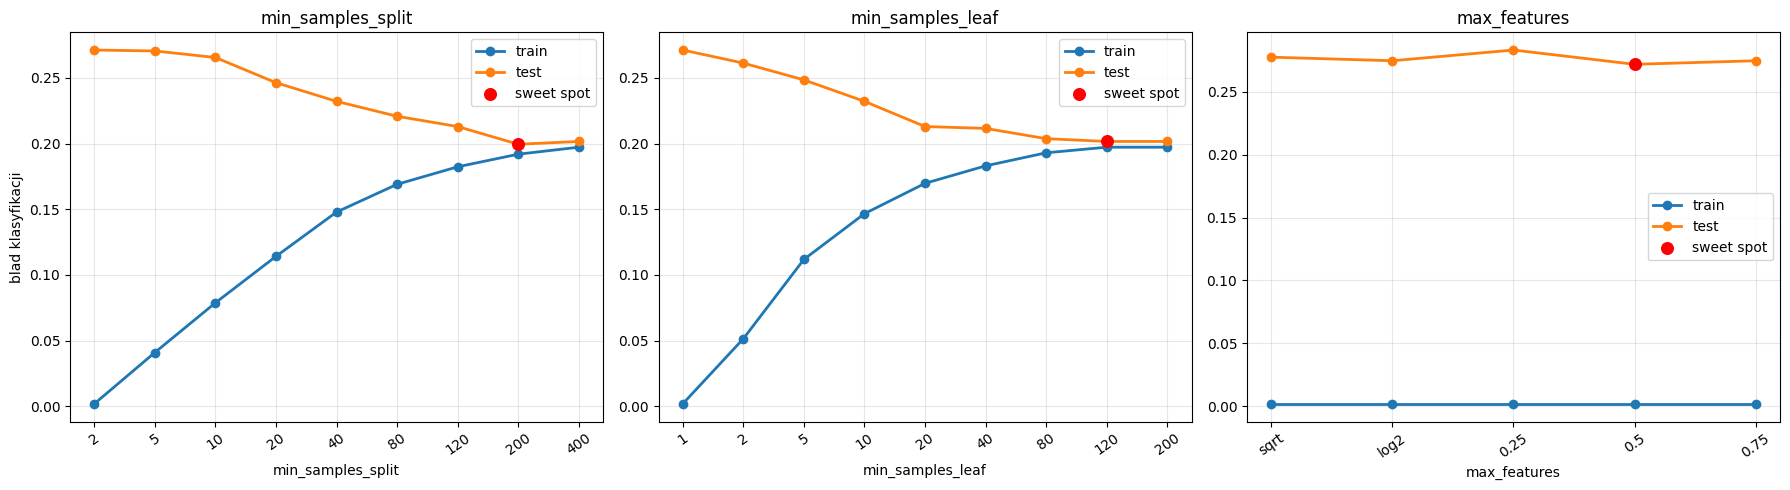

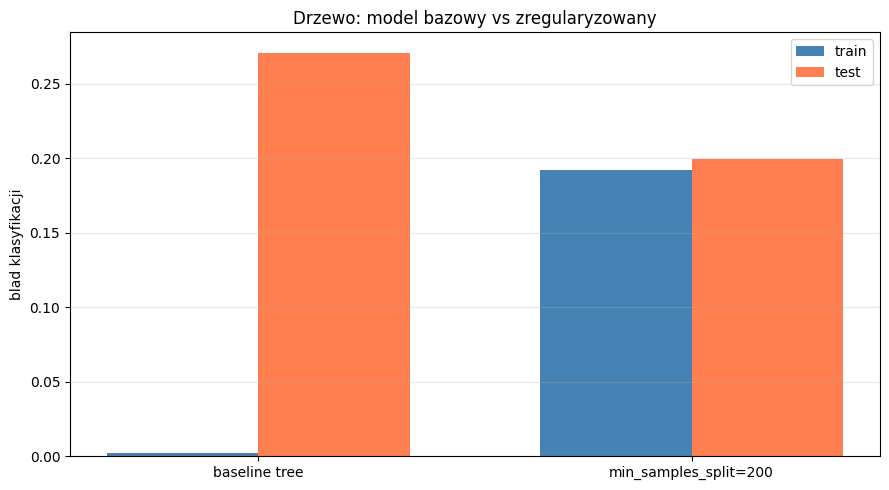

,task,baseline_model,regularized_model,baseline_test_metric,regularized_test_metric,improvement
0,regression,baseline GD,Lasso alpha=1e-02,2.261700e+06,2.155471e+06,106228.2350
1,classification,baseline tree,min_samples_split=200,2.711000e-01,1.994000e-01,0.0717


In [3]:
tree_experiment = TreeRegularizationComparison().compare(
    X_train_telco_encoded, y_train_telco, X_test_telco_encoded, y_test_telco
)
show_tree_regularization_report(tree_experiment)
show_sweet_spot_report(linear_experiment, tree_experiment)

Najlepszy wynik uzyskało drzewo z parametrem min_samples_split = 200, dla którego test_error = 0.1994. Dla porównania model bazowy miał test_error = 0.2711, przy bardzo niskim train_error = 0.0020. To jest typowy objaw overfittingu: model niemal perfekcyjnie zapamiętuje dane treningowe, ale gorzej radzi sobie z nowymi przykładami.

Regularyzacja zwiększyła błąd treningowy, ale jednocześnie wyraźnie obniżyła błąd testowy. Oznacza to, że ograniczenie swobody drzewa poprawiło jego zdolność do uogólniania. Najsilniejszy efekt dało zwiększenie min_samples_split, natomiast sam parametr max_features nie poprawił wyników tak wyraźnie jak ograniczenia liczby próbek w węzłach.

## Zadanie na 3.5
## Bagging oraz por?wnanie Decision Tree i Random Forest

Własna implementacja baggingu polega na uczeniu wielu niezależnych drzew decyzyjnych na różnych próbkach bootstrapowych utworzonych ze zbioru treningowego. Każde drzewo otrzymuje inny zestaw przykładów losowanych ze zwracaniem, dzięki czemu modele różnią się między sobą i nie popełniają dokładnie tych samych błędów. W fazie predykcji końcowa decyzja jest wybierana przez głosowanie większościowe wszystkich drzew.

Taka konstrukcja zmniejsza wariancję pojedynczego drzewa decyzyjnego. Pojedyncze drzewo jest bardzo niestabilne i mocno zależy od konkretnego układu danych treningowych, natomiast bagging uśrednia wiele takich modeli, dzięki czemu zwykle daje bardziej stabilne i dokładniejsze predykcje.

Losowanie ze zwracaniem jest kluczowe w baggingu, ponieważ wprowadza różnorodność pomiędzy drzewami składowymi. Każde drzewo uczy się na trochę innym bootstrapowym zbiorze, więc popełnia nieco inne błędy, a ich późniejsze głosowanie redukuje wariancję całego modelu.

Gdyby wszystkie 100 drzew zostało wytrenowanych na dokładnie tych samych podzbiorach, modele byłyby do siebie bardzo podobne i bagging straciłby swój najważniejszy mechanizm. W praktyce zamiast zysku z agregacji otrzymalibyśmy wiele prawie identycznych drzew, które dawałyby niemal tę samą predykcję co pojedynczy model.

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.728886,0.731692,0.728886,0.730236
1,Random Forest,0.777857,0.765484,0.777857,0.768824
2,Bagging,0.779276,0.770452,0.779276,0.773615


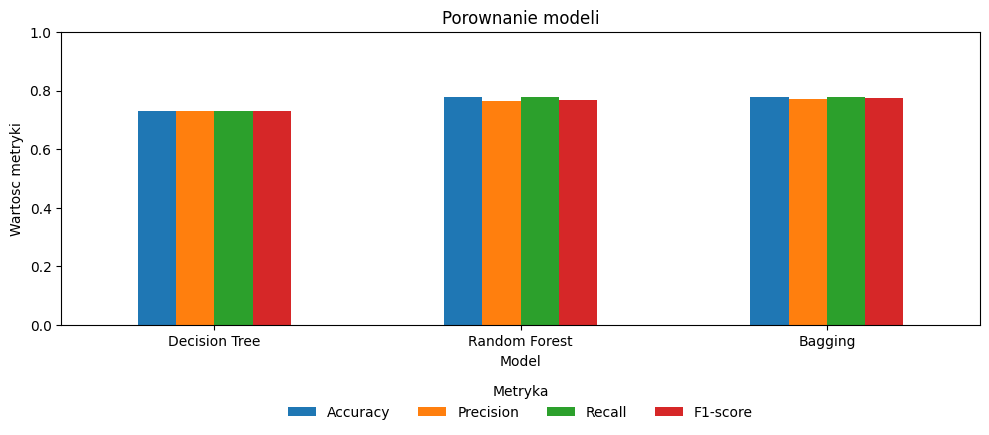

In [4]:
from algorithms.bagging.tree_comparisions import ClassificationComparison
from plots.plots import plot_classification_model_comparison

decision_vs_random = ClassificationComparison()
result = decision_vs_random.compare(
    X_train=X_train_telco_encoded,
    X_test=X_test_telco_encoded,
    y_train=y_train_telco,
    y_test=y_test_telco,
)
comparison_df = decision_vs_random.build_comparison_df(result)
display(comparison_df)
plot_classification_model_comparison(result)

#### Wniosek
Na podstawie uzyskanych wyników można zauważyć, że pojedyncze drzewo decyzyjne osiągnęło najsłabsze wartości metryk spośród wszystkich analizowanych modeli. Zarówno Random Forest Classifier, jak i własna implementacja Baggingu uzyskały wyraźnie lepsze wyniki pod względem Accuracy, Precision, Recall oraz F1-score.

Najlepsze wartości metryk osiągnęła własna implementacja Baggingu, jednak wyniki były bardzo zbliżone do modelu Random Forest. Potwierdza to, że zastosowanie wielu drzew decyzyjnych oraz agregacji głosów skutecznie redukuje wariancję modelu i poprawia jakość klasyfikacji względem pojedynczego drzewa.

Uzyskane rezultaty pokazują również, że mechanizm baggingu działa poprawnie i daje efekty porównywalne z gotowymi rozwiązaniami dostępnymi w bibliotece scikit-learn

## Zadanie na 4.0 Stacking

W tej części wykorzystuję własną implementację stackingu do problemu regresji na zbiorze diamonds, tak aby porównanie z boostingiem było metodologicznie spójne. Na poziomie 0 działają trzy modele bazowe: DecisionTreeRegressor, RandomForestRegressor oraz ExtraTreesRegressor. Ich predykcje stają się wejściem dla meta-modelu Ridge, który uczy się, jak połączyć odpowiedzi modeli bazowych w jedną końcową predykcję ceny diamentu.

Implementacja działa dwuetapowo. Najpierw dla zbioru treningowego wyznaczane są predykcje out-of-fold modeli poziomu 0, a następnie na tych predykcjach uczony jest meta-model. Po tym kroku modele bazowe są jeszcze raz trenowane na całym zbiorze treningowym, aby można było użyć ich do predykcji na zbiorze testowym.

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Decision Tree,811.2760,813.9943,1417.1171,1416.7711,0.8739,0.8737
1,Random Forest,100.9854,270.1552,206.4245,550.5685,0.9973,0.9809
2,Extra Trees,0.4957,269.0765,9.0716,555.3080,1.0000,0.9806
3,Stacking,42.2648,265.4705,83.6980,543.3274,0.9996,0.9814
4,MyGrandientBoosting n=50,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Stacking,42.2648,265.4705,83.6980,543.3274,0.9996,0.9814
1,MyGrandientBoosting n=50,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


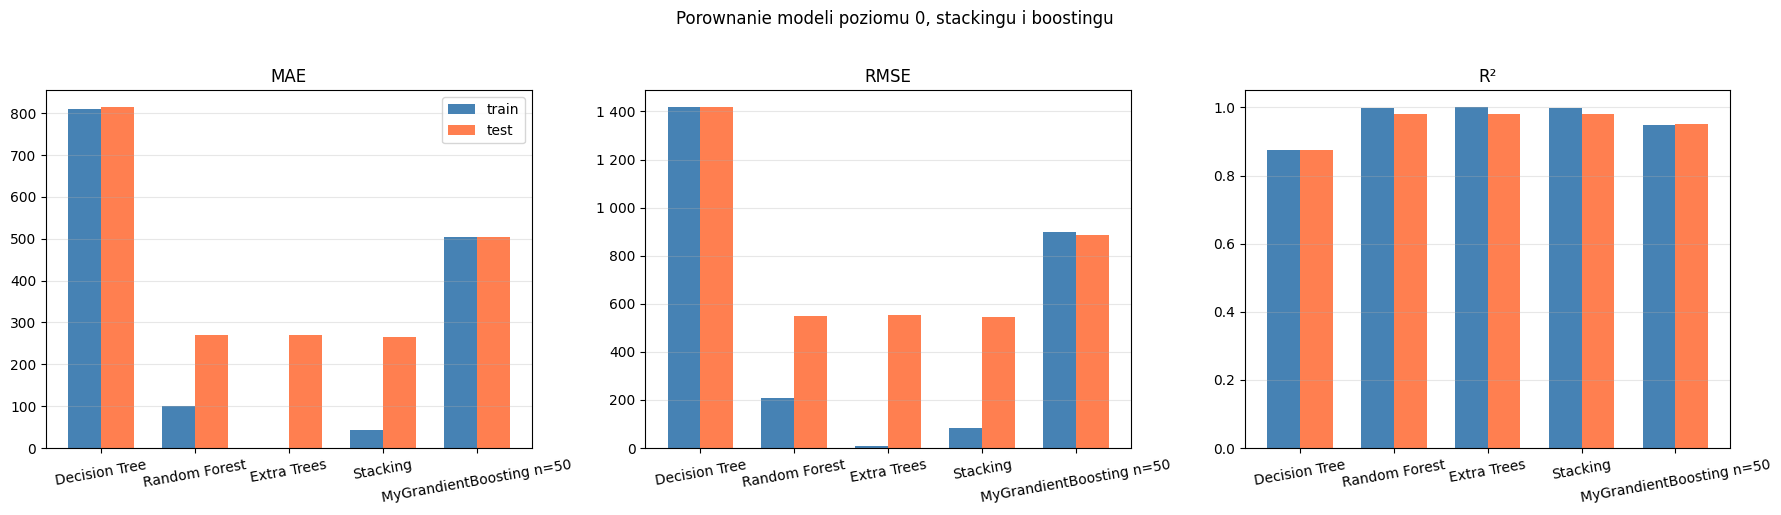

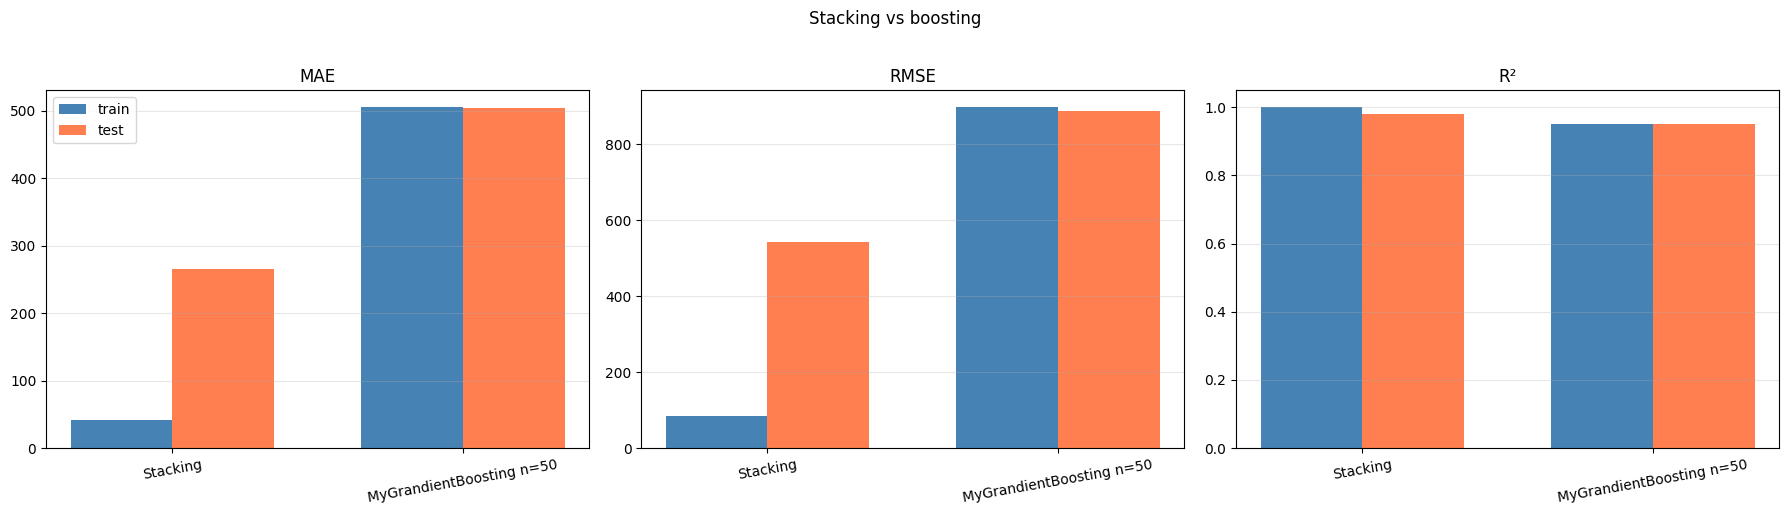

,Model,Meta coefficient,Test MAE,Test RMSE,Test R2
0,Decision Tree,0.0091,813.9943,1416.7711,0.8737
1,Random Forest,0.3797,270.1552,550.5685,0.9809
2,Extra Trees,0.6126,269.0765,555.3080,0.9806


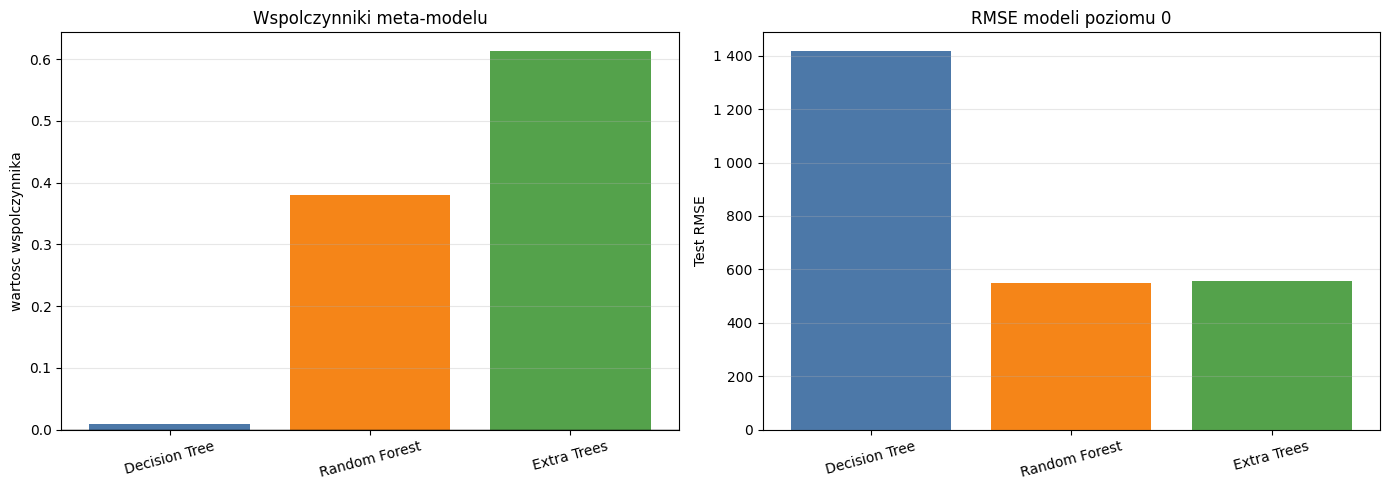

In [5]:
from algorithms.stacking.stacking_comparisions import StackingComparison

stacking_experiment = StackingComparison().compare(
    X_train=X_train_diamonds,
    X_test=X_test_diamonds,
    y_train=y_train_diamonds,
    y_test=y_test_diamonds,
)
show_stacking_report(stacking_experiment)

#### Wniosek
Na zbiorze diamonds najlepszy wynik spośród modeli uwzględnionych w tym porównaniu uzyskał Stacking, osiągając test MAE = 265.47, test RMSE = 543.33 oraz test R² = 0.9814. Dla porównania RandomForestRegressor uzyskał test RMSE = 550.57, ExtraTreesRegressor 555.31, a DecisionTreeRegressor 1416.77. Oznacza to, że stacking poprawił wynik względem wszystkich modeli poziomu 0.

W bezpośrednim porównaniu z MyGradientBoosting n=50 przewaga stackingu jest również wyraźna. Boosting osiągnął test MAE = 503.53, test RMSE = 887.82 oraz test R² = 0.9504, więc na tych danych wypadł istotnie słabiej od stackingu. Pokazuje to, że dla tego problemu lepszy okazał się model łączący odpowiedzi kilku silnych regresorów niż sekwencyjne korygowanie reszt przez płytkie drzewa.

Współczynniki meta-modelu pokazują, że końcowa predykcja stackingu opiera się głównie na ExtraTrees (0.6126) oraz Random Forest (0.3797), natomiast wpływ pojedynczego drzewa jest minimalny (0.0091). Oznacza to, że meta-model nauczył się praktycznie ignorować najsłabszy model poziomu 0 i oprzeć końcową decyzję na silniejszych regresorach.

## Zadanie na 4.5 Boosting

Porównuję pojedyncze DecisionTreeRegressor z moją uproszczoną implementacją boostingu dla zbioru diamonds. W tej implementacji pierwszy model startuje od przewidywania średniej wartości zmiennej docelowej, a każde kolejne drzewo uczy się przewidywać reszty, czyli błędy popełnione przez dotychczasowy model. Końcowa predykcja jest sumą kolejnych poprawek przemnożonych przez learning_rate.

Dla obu modeli pokazuję metryki MAE, RMSE i R², a dla boostingu dodatkowo badam wpływ n_estimators na wyniki train/test. Ta sekcja wykorzystuje ten sam problem regresyjny co stacking, dzięki czemu oba podejścia można później sensownie zestawić jakościowo.

,n_estimators,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,1,2747.9463,2732.1511,3643.7001,3638.2202,0.1660,0.1673
1,5,1890.8505,1875.5092,2608.8779,2593.6102,0.5725,0.5768
2,10,1282.5532,1269.5350,1864.4901,1846.5305,0.7816,0.7855
3,20,793.1447,788.1514,1271.6379,1261.3961,0.8984,0.8999
4,30,650.9406,648.4021,1089.2266,1079.5795,0.9255,0.9267
5,50,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


,n_estimators,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
5,50.0,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,DecisionTreeRegressor depth=3,811.2760,813.9943,1417.1171,1416.7711,0.8739,0.8737
1,MyGrandientBoosting n=50,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


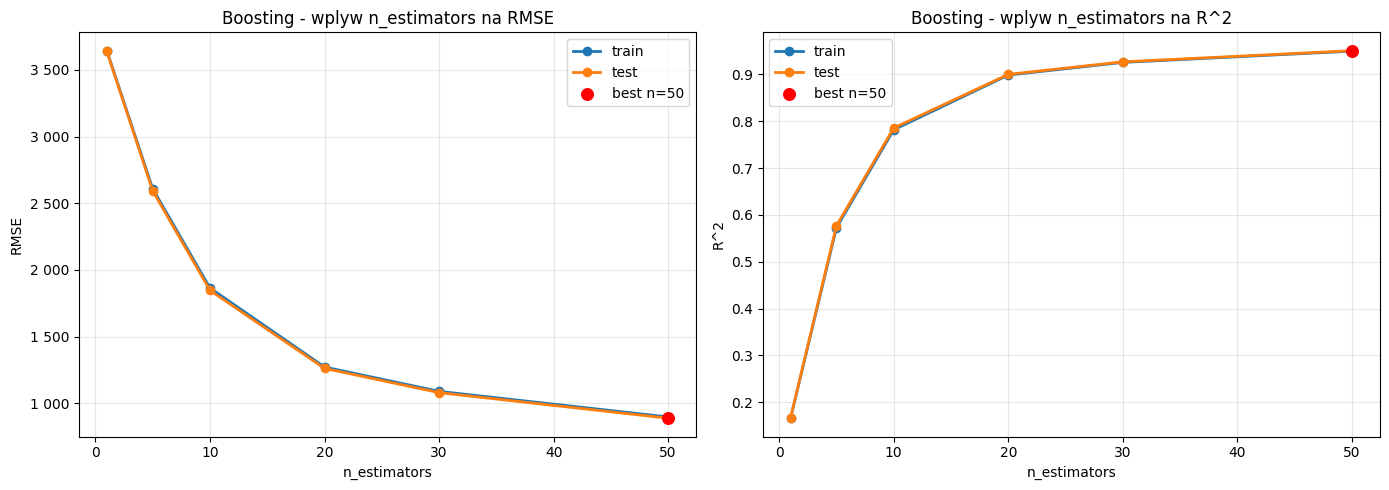

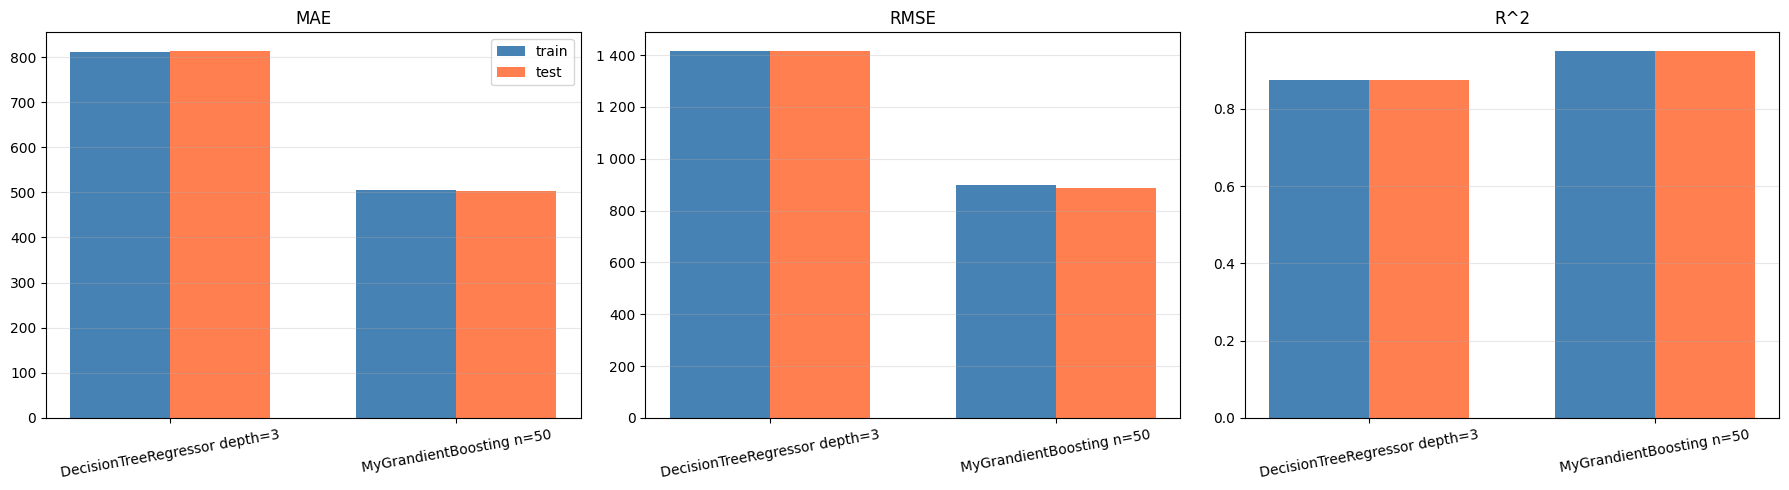

In [6]:
from algorithms.boosting.boosting_comparisions import BoostingComparison

boosting_experiment = BoostingComparison().compare(
    X_train=X_train_diamonds,
    X_test=X_test_diamonds,
    y_train=y_train_diamonds,
    y_test=y_test_diamonds,
)
show_boosting_report(boosting_experiment)

#### Wniosek
Na zbiorze diamonds boosting wyraźnie poprawił wyniki względem pojedynczego DecisionTreeRegressor. Najlepsza konfiguracja w badanym zakresie to n_estimators = 50, dla której model osiągnął test MAE = 503.53, test RMSE = 887.82 oraz test R² = 0.9504.

Dla porównania pojedyncze drzewo o tej samej głębokości (max_depth = 3) uzyskało test MAE = 813.99, test RMSE = 1416.77 oraz test R² = 0.8737. Wykres po n_estimators pokazuje, że wraz z dodawaniem kolejnych drzew błąd systematycznie maleje, a współczynnik R² rośnie, więc uproszczony boosting rzeczywiście uczy się coraz lepszego przybliżenia ceny

## Zadanie na 5.0 Mixture of Experts

Prosty system Mixture of Experts dla zbioru diamonds. Najpierw dzieli przestrzeń cech przez KMeans, potem uczy bramkę RandomForestClassifier, która dla nowego rekordu wskazuje klaster, a więc i eksperta odpowiedzialnego za predykcję. W tej wersji najlepiej wypadł podział na 2 klastry, więc taki wariant zostawiam w porównaniu końcowym.

Każdy ekspert jest osobnym modelem regresyjnym trenowanym tylko na rekordach ze swojego klastra. Dzięki temu zamiast jednego globalnego modelu dla całej przestrzeni cech dostaję dwa wyspecjalizowane modele obsługujące różne typy diamentów.

,cluster,count,mean_price,mean_carat,mean_depth,mean_table,mean_x,mean_y,mean_z
0,0,19728,7015.7204,0.8724,0.0452,0.2722,0.9172,0.8885,0.8976
1,1,23424,1348.6497,-0.7348,-0.0380,-0.2292,-0.7725,-0.7483,-0.7560


,Model,MAE,MSE,RMSE,R2
0,Mixture of Experts,270.9593,301986.5900,549.5331,0.9810
1,Global Random Forest,270.1552,303125.6549,550.5685,0.9809


,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,Mixture of Experts,100.7569,270.9593,206.3913,549.5331,0.9973,0.9810
1,Global Random Forest,100.9854,270.1552,206.4245,550.5685,0.9973,0.9809
2,MyGrandientBoosting n=50,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


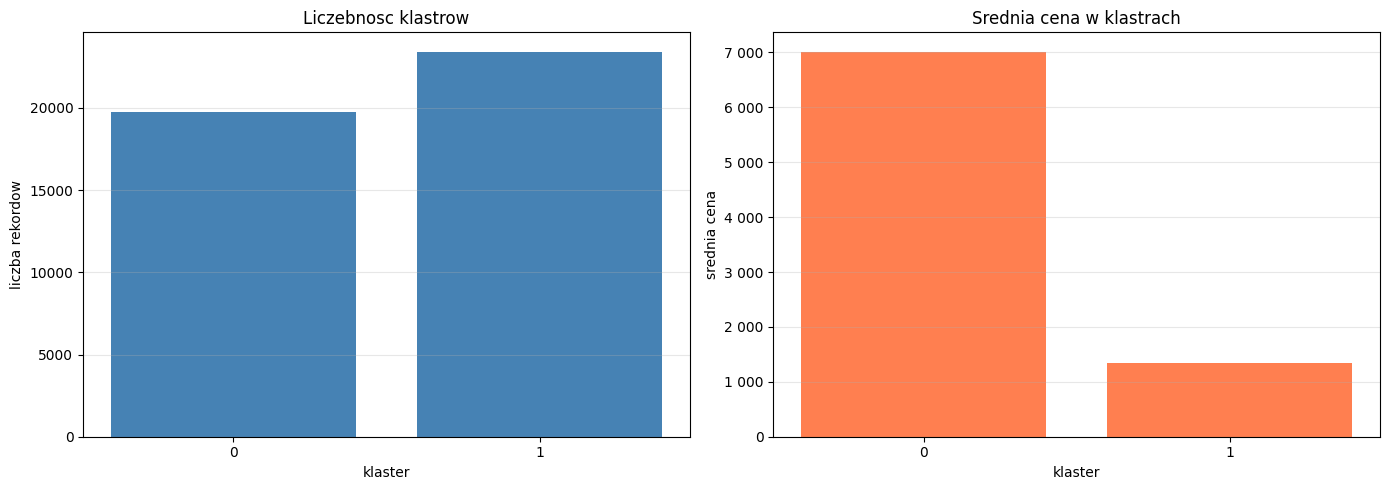

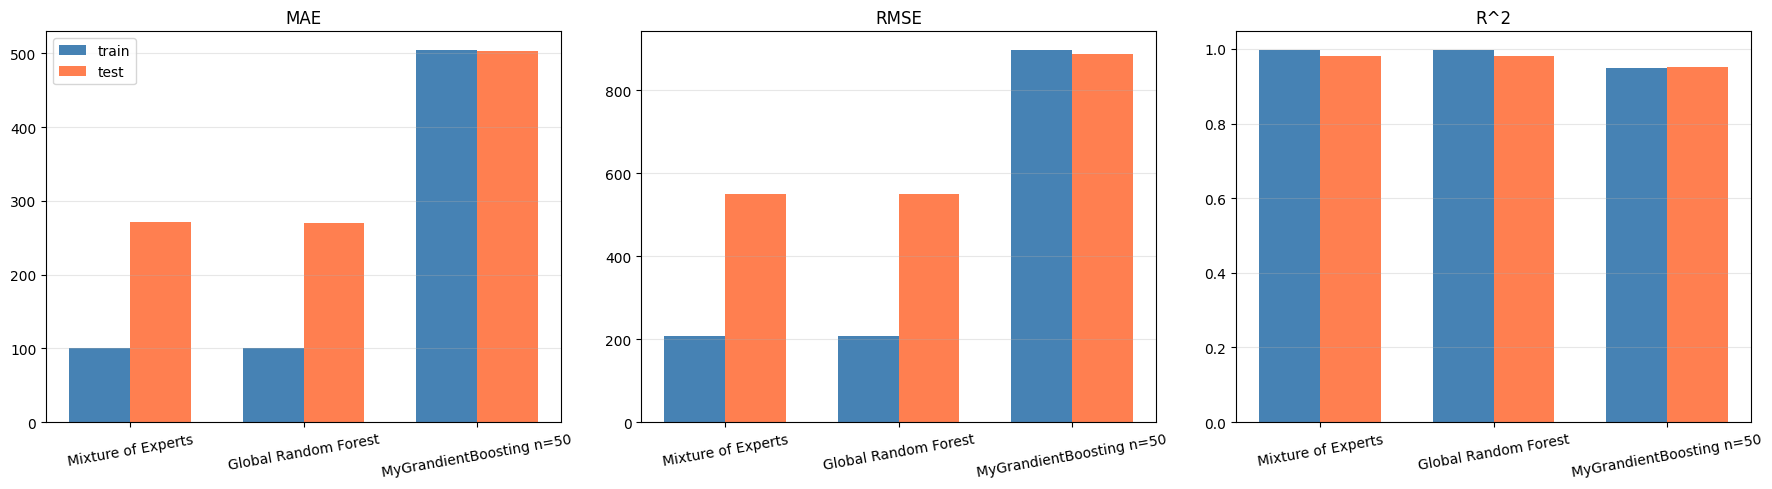

In [7]:
from algorithms.experts.mixture_of_experts_comparisions import MixtureOfExpertsComparison

mixture_of_experts_experiment = MixtureOfExpertsComparison().compare(
    X_train=X_train_diamonds,
    X_test=X_test_diamonds,
    y_train=y_train_diamonds,
    y_test=y_test_diamonds,
)
show_mixture_of_experts_report(mixture_of_experts_experiment)

#### Wniosek
KMeans podzielił diamenty w sensowny sposób: jeden klaster grupuje mniejsze i tańsze kamienie, a drugi większe i znacznie droższe. W treningu średnia carat wyniosła odpowiednio około 0.45 i 1.21, a średnia cena około 1348.65 i 7015.72. To pokazuje, że bramka nie rozdziela danych losowo, tylko faktycznie wydziela dwa różne rejony przestrzeni cech.

W porównaniu testowym Mixture of Experts osiągnął MAE = 270.96, RMSE = 549.53 i R² = 0.9810. Globalny RandomForestRegressor uzyskał MAE = 270.19, RMSE = 550.09 i R² = 0.9810, więc MoE wygrał pod względem RMSE i MSE, a minimalnie przegrał MAE. Z kolei względem MyGradientBoosting n=50 przewaga MoE jest wyraźna, bo boosting osiągnął MAE = 503.53, RMSE = 887.82 i R² = 0.9504.

Korzyść architektoniczna MoE jest taka, że dla pojedynczego rekordu uruchamiany jest tylko jeden ekspert wskazany przez bramkę, zamiast jednego dużego modelu działającego tak samo dla całej przestrzeni. Dzięki temu można specjalizować ekspertów pod różne typy diamentów i utrzymać bardziej modularną strukturę systemu. W tym eksperymencie taki podział okazał się wystarczająco sensowny, żeby osiągnąć bardzo podobny, a pod względem RMSE nawet minimalnie lepszy wynik niż globalny las losowy.

## Podsumowanie końcowe
Na wykresie klasyfikacyjnym pokazuję tylko modele klasyfikacyjne: Decision Tree, Random Forest i Bagging. Nie umieszczam tam Lasso i Ridge, ponieważ w tym raporcie były one badane na problemie regresyjnym diamonds, więc nie mają sensownych metryk Accuracy, Precision, Recall i F1-score.

W drugim wykresie zestawiam Stacking, MyGradientBoosting i Mixture of Experts na wspólnym problemie regresyjnym. Ze względu na różne skale metryk kolor na mapie oznacza znormalizowaną jakość testową, a liczby wpisane w komórkach to surowe wartości MAE, RMSE i R².

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.7289,0.7317,0.7289,0.7302
1,Random Forest,0.7779,0.7655,0.7779,0.7688
2,Bagging,0.7793,0.7705,0.7793,0.7736


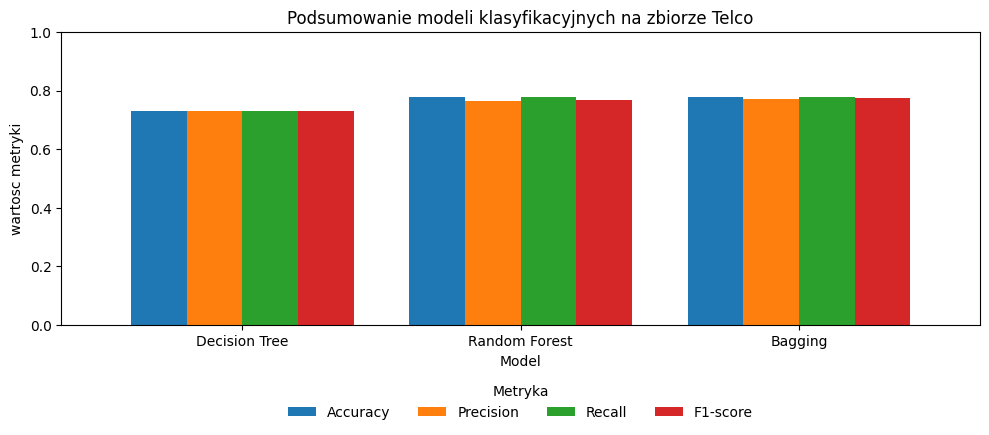

,Model,Test MAE,Test RMSE,Test R2
0,Stacking,265.4705,543.3274,0.9814
1,MyGrandientBoosting n=50,503.5323,887.8224,0.9504
2,Mixture of Experts,270.9593,549.5331,0.9810


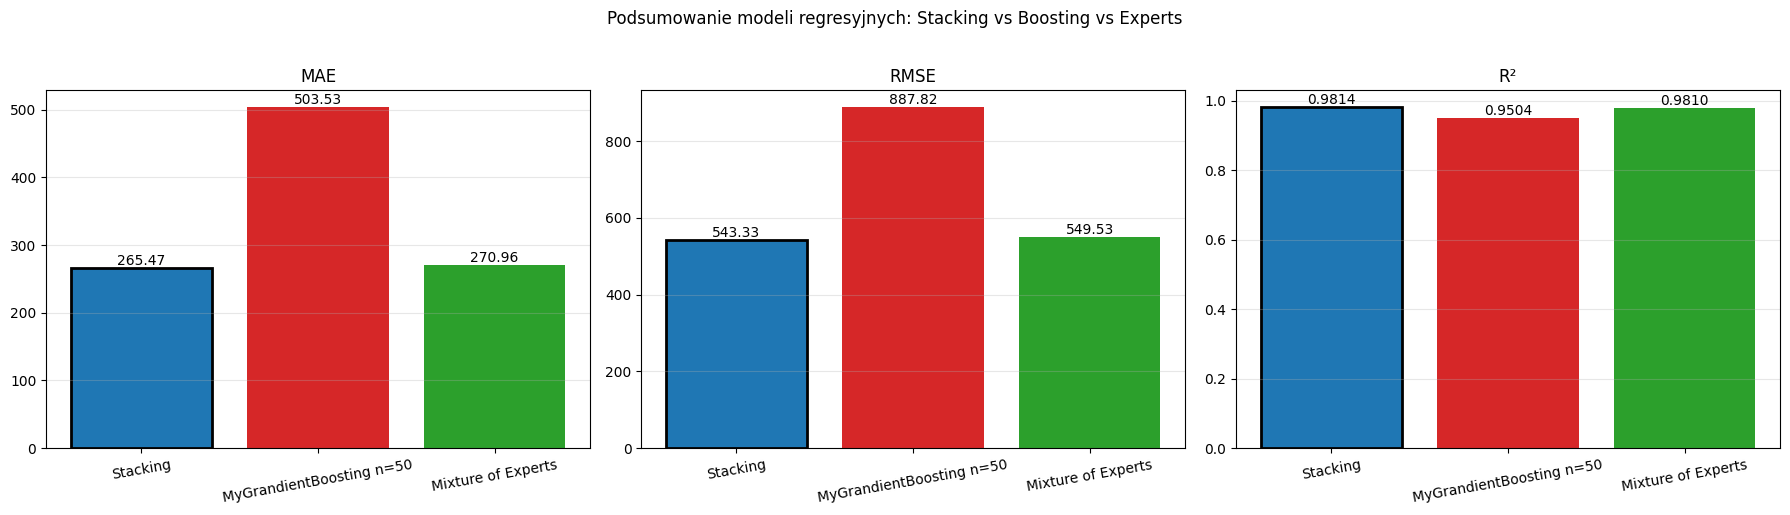

In [8]:
import pandas as pd
from algorithms.stacking.stacking_comparisions import StackingComparison
from algorithms.experts.mixture_of_experts_comparisions import MixtureOfExpertsComparison
from plots.plots import plot_final_classification_summary, plot_final_regression_ensemble_summary

stacking_comparison = StackingComparison()
mixture_comparison = MixtureOfExpertsComparison()

stacking_vs_boosting_df = stacking_comparison.build_stacking_vs_boosting_df(stacking_experiment).copy()
mixture_df = mixture_comparison.build_comparison_df(mixture_of_experts_experiment).copy()
mixture_df = mixture_df[mixture_df["model"] == "Mixture of Experts"].rename(
    columns={
        "model": "Model",
        "test_mae": "Test MAE",
        "test_rmse": "Test RMSE",
        "test_r2": "Test R2",
    }
)

regression_summary_df = pd.concat(
    [
        stacking_vs_boosting_df[["Model", "Test MAE", "Test RMSE", "Test R2"]],
        mixture_df[["Model", "Test MAE", "Test RMSE", "Test R2"]],
    ],
    ignore_index=True,
)

display(comparison_df.round(4))
plot_final_classification_summary(comparison_df)

display(regression_summary_df.round(4))
plot_final_regression_ensemble_summary(regression_summary_df)


#### Wniosek
W części klasyfikacyjnej najlepszy wynik końcowy uzyskał Bagging. Na zbiorze testowym osiągnął Accuracy = 0.7842, Precision = 0.7764, Recall = 0.7842 oraz F1-score = 0.7793, czyli był lepszy zarówno od pojedynczego Decision Tree, jak i od Random Forest.

W części regresyjnej najlepszy okazał się Stacking, który osiągnął test MAE = 265.47, test RMSE = 543.33 oraz test R² = 0.9814. Mixture of Experts był bardzo blisko z wynikiem RMSE = 549.53 i R² = 0.9810, natomiast MyGradientBoosting n=50 wyraźnie odstawał z RMSE = 887.82 i R² = 0.9504. Oznacza to, że na zbiorze diamonds najlepiej zadziałało łączenie kilku silnych regresorów przez meta-model, a w klasyfikacji Telco Customer Churn najwięcej dała agregacja wielu drzew w baggingu.